In [19]:
# ==========================================
# CS2 Pro Settings 2026 — Data Visualization Report
# ==========================================
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# ---- 0. CJK Font Detection (Windows-first fallback) ----
available_fonts = {f.name for f in fm.fontManager.ttflist}
cjk_candidates = [
    'Microsoft YaHei', 'SimHei',               # Windows
    'PingFang SC', 'Heiti SC', 'STHeiti',       # macOS
    'Noto Sans CJK SC', 'WenQuanYi Micro Hei',  # Linux
    'Arial Unicode MS',                          # fallback
]
found = [f for f in cjk_candidates if f in available_fonts]
plt.rcParams['font.sans-serif'] = found + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False
print(f"Font: {found[0] if found else 'fallback'}")

# ---- 1. CS2 Cyberpunk Theme ----
def setup_cs2_theme():
    warnings.filterwarnings('ignore')
    plt.style.use('dark_background')
    sns.set_palette(["#00E5FF", "#FF4500", "#00FF00", "#FF00FF", "#FFFF00"])
    sns.set_context("notebook", font_scale=1.1)
    plt.rcParams.update({
        'axes.facecolor': '#121212', 'figure.facecolor': '#0a0a0a',
        'grid.color': '#333333', 'grid.linestyle': '--',
        'axes.edgecolor': '#555555', 'text.color': '#E0E0E0',
        'axes.labelcolor': '#E0E0E0', 'xtick.color': '#A0A0A0',
        'ytick.color': '#A0A0A0',
    })
    print("Theme: CS2 Cyberpunk Dark")

# ---- 2. Chart Factories ----
def bar(ax, data, x_col, y_col=None, title="", palette="cool", orient='v'):
    if orient == 'v':
        sns.barplot(data=data, x=x_col, y=y_col, palette=palette, ax=ax, edgecolor='#121212')
    else:
        sns.barplot(data=data, x=x_col, y=y_col, palette=palette, ax=ax, edgecolor='#121212', orient='h')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    sns.despine(ax=ax, left=True, bottom=True)
    if orient == 'v':
        for p in ax.patches:
            h = p.get_height()
            if not np.isnan(h) and h > 0:
                ax.annotate(f"{int(h)}", (p.get_x()+p.get_width()/2., h),
                            ha='center', va='bottom', fontsize=12, fontweight='bold',
                            color='white', xytext=(0,5), textcoords='offset points')

def pie(ax, data, title="", palette_name="Set2"):
    colors = sns.color_palette(palette_name, len(data))
    _, _, at = ax.pie(data, labels=data.index, autopct='%1.1f%%', startangle=140,
                       colors=colors, wedgeprops={'edgecolor':'#121212','linewidth':2})
    plt.setp(at, size=11, weight="bold", color="white")
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)

def hist(ax, data, title="", color="#00E5FF", bins=30, show_stats=False):
    clean = pd.to_numeric(pd.Series(data), errors='coerce').dropna()
    sns.histplot(clean, bins=bins, kde=True, color=color, edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    sns.despine(ax=ax, left=True, bottom=True)
    if show_stats and len(clean) > 0:
        ax.axvline(clean.mean(), color='#FFFF00', linestyle='-.', linewidth=1.8,
                   label=f'Mean: {clean.mean():.1f}')
        ax.axvline(clean.median(), color='#FF4500', linestyle='--', linewidth=1.8,
                   label=f'Median: {clean.median():.1f}')
        ax.legend(loc='upper right', facecolor='#121212')

def save(name):
    plt.savefig(f'figures/{name}', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')

# ---- 3. Load Data ----
setup_cs2_theme()
df = pd.read_csv('data/cs2_pro_2026_Active_Final.csv')
print(f"Loaded: {len(df)} players, {df['Team'].nunique()} teams")

Font: STHeiti
Theme: CS2 Cyberpunk Dark
Loaded: 198 players, 41 teams


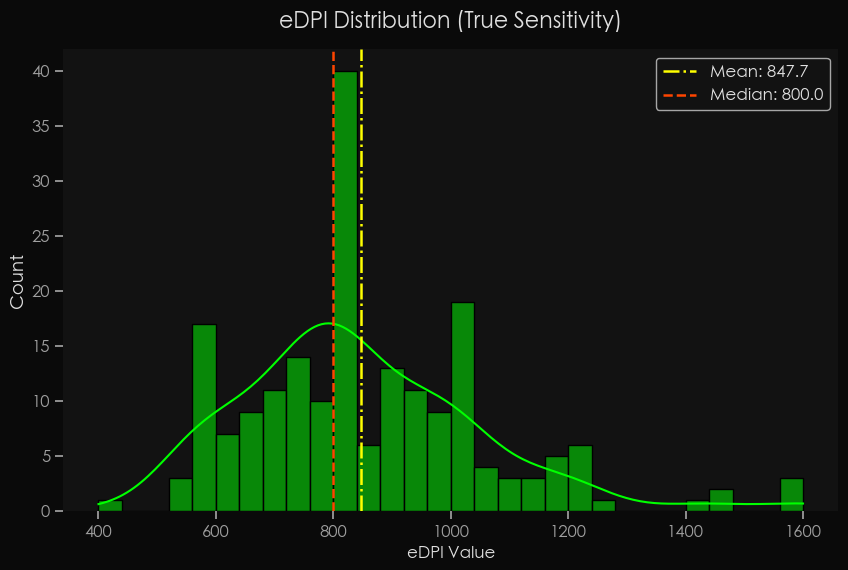

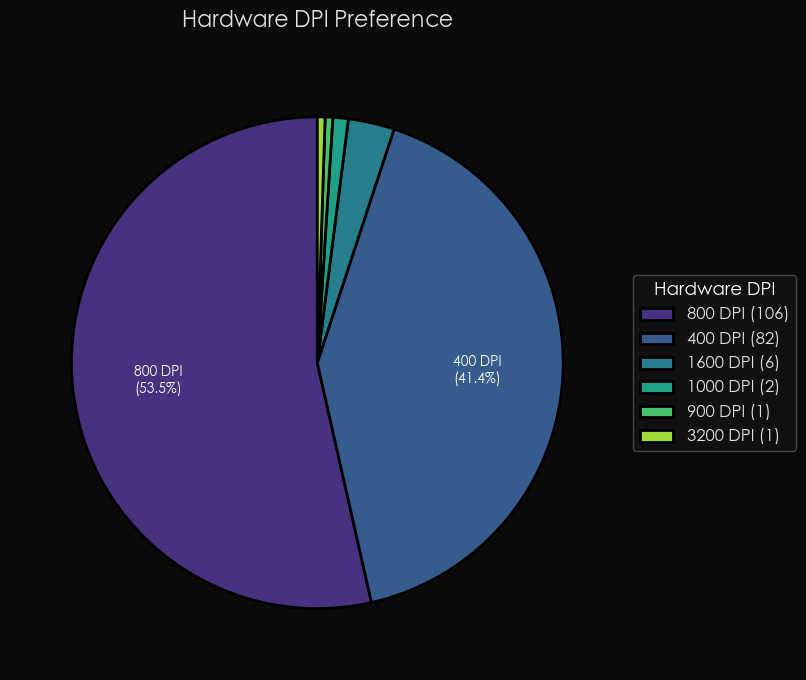

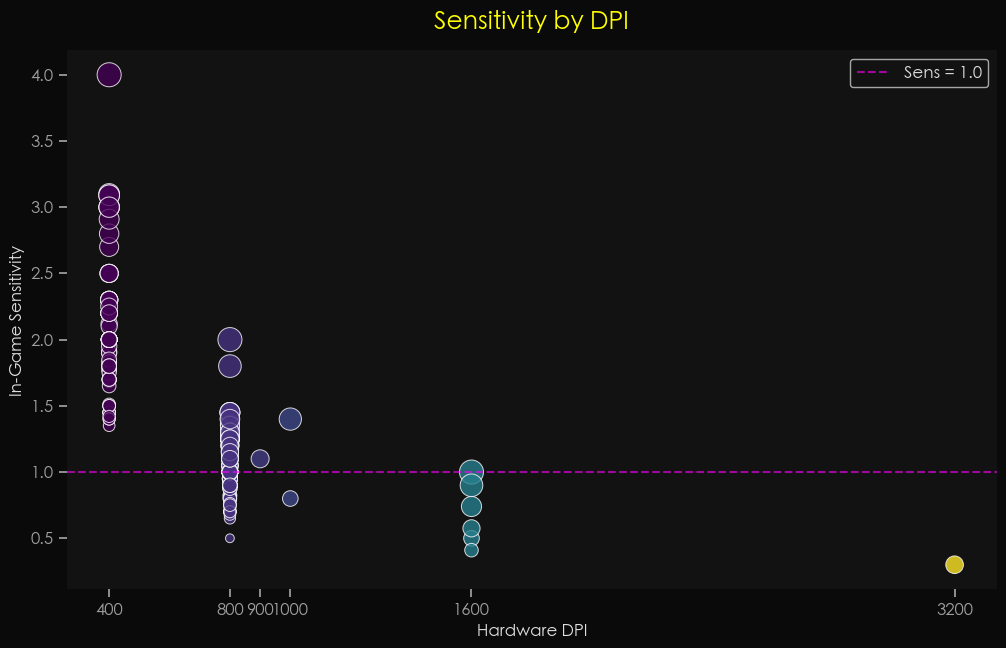

In [20]:
# ---- eDPI Distribution ----
fig, ax = plt.subplots(figsize=(10, 6))
hist(ax, df['eDPI'], title="eDPI Distribution (True Sensitivity)", color="#00FF00", show_stats=True)
ax.set_xlabel('eDPI Value', fontsize=12)
save('eDPI.png'); plt.show()

# ---- Hardware DPI (legend outside) ----
fig, ax = plt.subplots(figsize=(10, 7))
dpi_counts = df['DPI'].value_counts()
colors = sns.color_palette("viridis", len(dpi_counts))
wedges, _ = ax.pie(dpi_counts, startangle=90, colors=colors,
                    wedgeprops={'edgecolor': 'black', 'linewidth': 2})
# Only label slices >= 5%
for i, (w, pct) in enumerate(zip(wedges, dpi_counts.values / dpi_counts.sum() * 100)):
    if pct >= 5:
        ang = (w.theta2 - w.theta1) / 2. + w.theta1
        x = 0.65 * np.cos(np.deg2rad(ang))
        y = 0.65 * np.sin(np.deg2rad(ang))
        ax.annotate(f'{dpi_counts.index[i]:.0f} DPI\n({pct:.1f}%)', xy=(x, y),
                     ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.legend(wedges, [f'{int(k)} DPI ({v})' for k, v in dpi_counts.items()],
          title="Hardware DPI", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
          facecolor='#121212', edgecolor='#555555').get_title().set_color('white')
ax.set_title('Hardware DPI Preference', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
save('DPI.png'); plt.show()

# ---- DPI vs Sensitivity Scatter ----
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(data=df, x='DPI', y='Sensitivity', hue='DPI', palette='viridis',
                size='eDPI', sizes=(40, 300), alpha=0.8, edgecolor='w', ax=ax, legend=False)
ax.axhline(1.0, color='#FF00FF', linestyle='--', alpha=0.6, label='Sens = 1.0')
ax.set_title('Sensitivity by DPI', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.set_xlabel('Hardware DPI', fontsize=12)
ax.set_ylabel('In-Game Sensitivity', fontsize=12)
ax.set_xticks(sorted(df['DPI'].dropna().unique()))
ax.legend(loc='upper right', facecolor='#121212')
sns.despine(ax=ax, left=True, bottom=True)
save('Sensitivity by DPI.png'); plt.show()

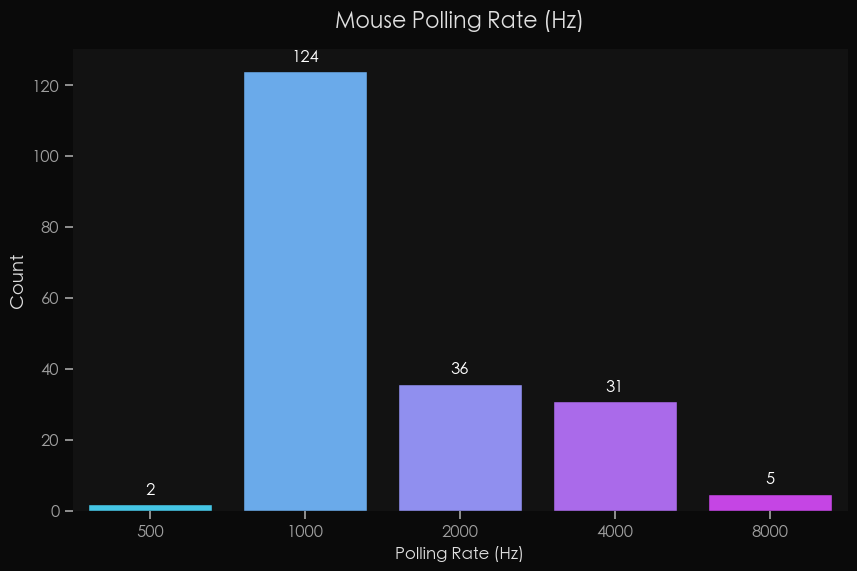

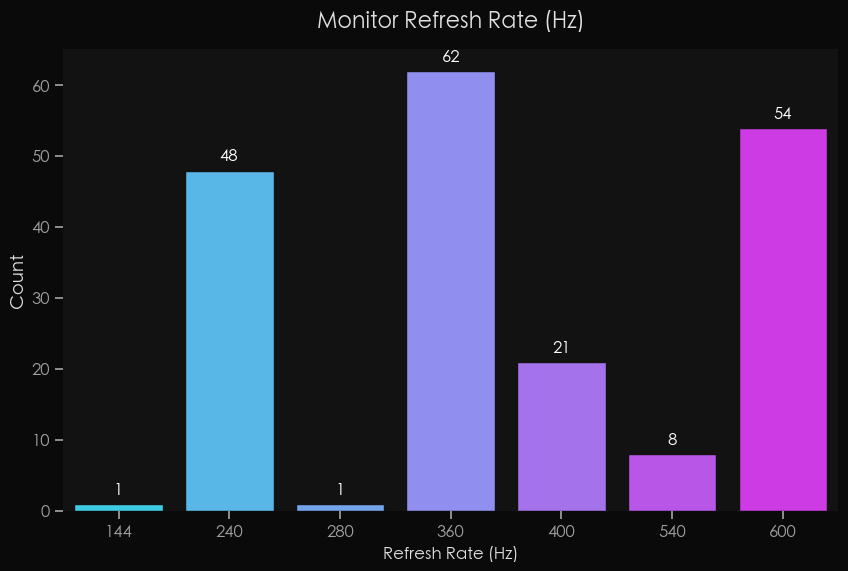

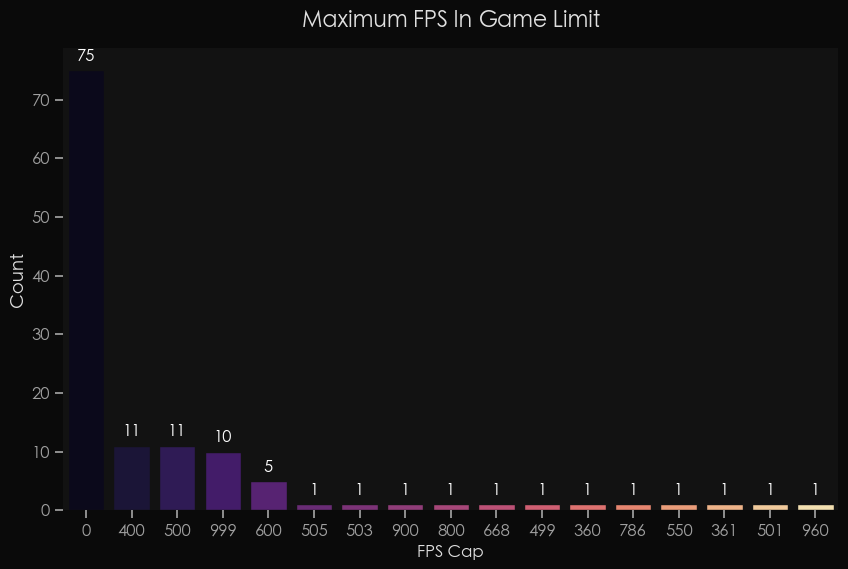

In [21]:
# ---- Mouse Polling Rate ----
fig, ax = plt.subplots(figsize=(10, 6))
hz = df.dropna(subset=['Hz'])['Hz'].value_counts().sort_index().reset_index()
hz.columns = ['Hz', 'Count']; hz['Hz'] = hz['Hz'].astype(int)
bar(ax, hz, x_col='Hz', y_col='Count', title="Mouse Polling Rate (Hz)", palette="cool")
ax.set_xlabel('Polling Rate (Hz)', fontsize=12)
save('Mouse Polling Rate.png'); plt.show()

# ---- Monitor Refresh Rate ----
fig, ax = plt.subplots(figsize=(10, 6))
df['Refresh_clean'] = df['Refresh Rate'].astype(str).str.extract(r'(\d+)').astype(float)
rr = df.dropna(subset=['Refresh_clean'])['Refresh_clean'].value_counts().sort_index().reset_index()
rr.columns = ['Hz', 'Count']; rr['Hz'] = rr['Hz'].astype(int)
bar(ax, rr, x_col='Hz', y_col='Count', title="Monitor Refresh Rate (Hz)", palette="cool")
ax.set_xlabel('Refresh Rate (Hz)', fontsize=12)
save('Monitor Hz.png'); plt.show()

# ---- FPS Cap ----
fig, ax = plt.subplots(figsize=(10, 6))
fps = df[df['Maximum FPS In Game'] != 'Unknown']['Maximum FPS In Game'].value_counts().reset_index()
fps.columns = ['FPS Cap', 'Count']
bar(ax, fps, x_col='FPS Cap', y_col='Count', title="Maximum FPS In Game Limit", palette="magma")
ax.set_xlabel('FPS Cap', fontsize=12)
save('Maximun FPS.png'); plt.show()

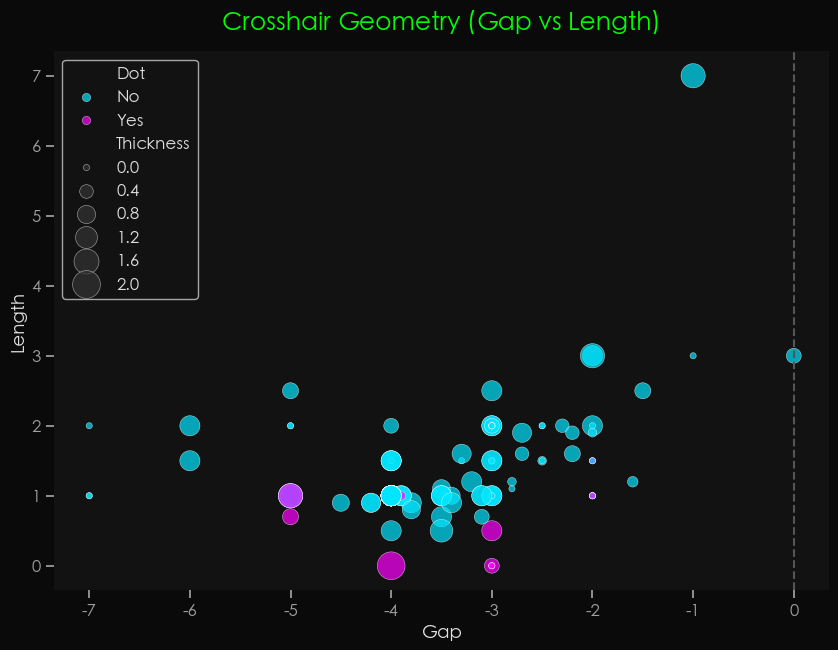

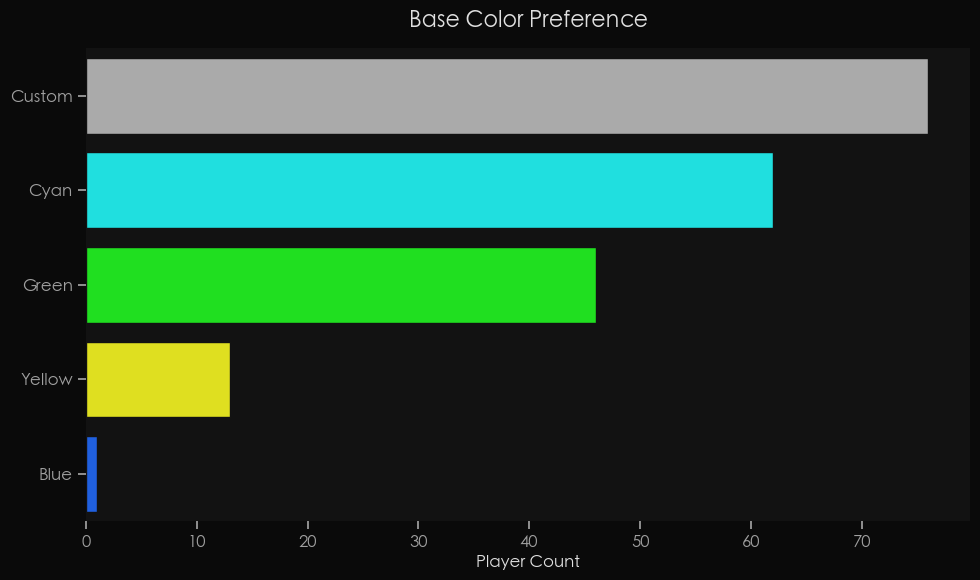

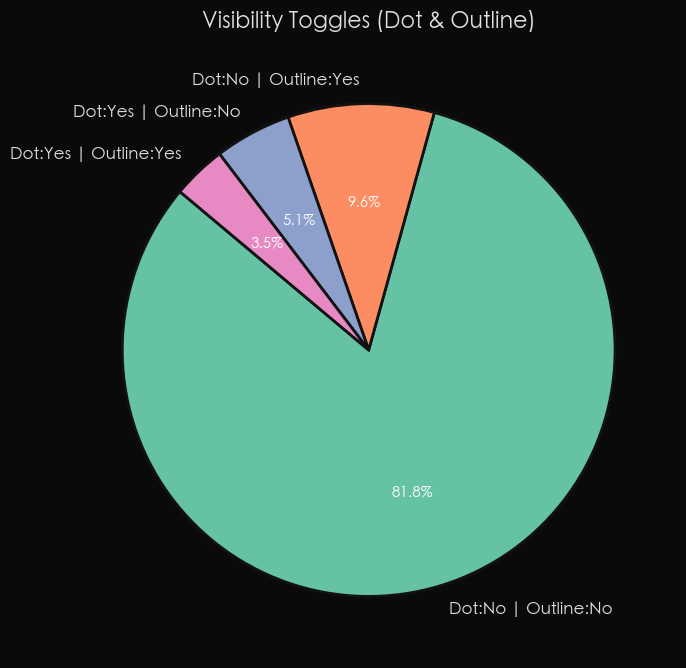

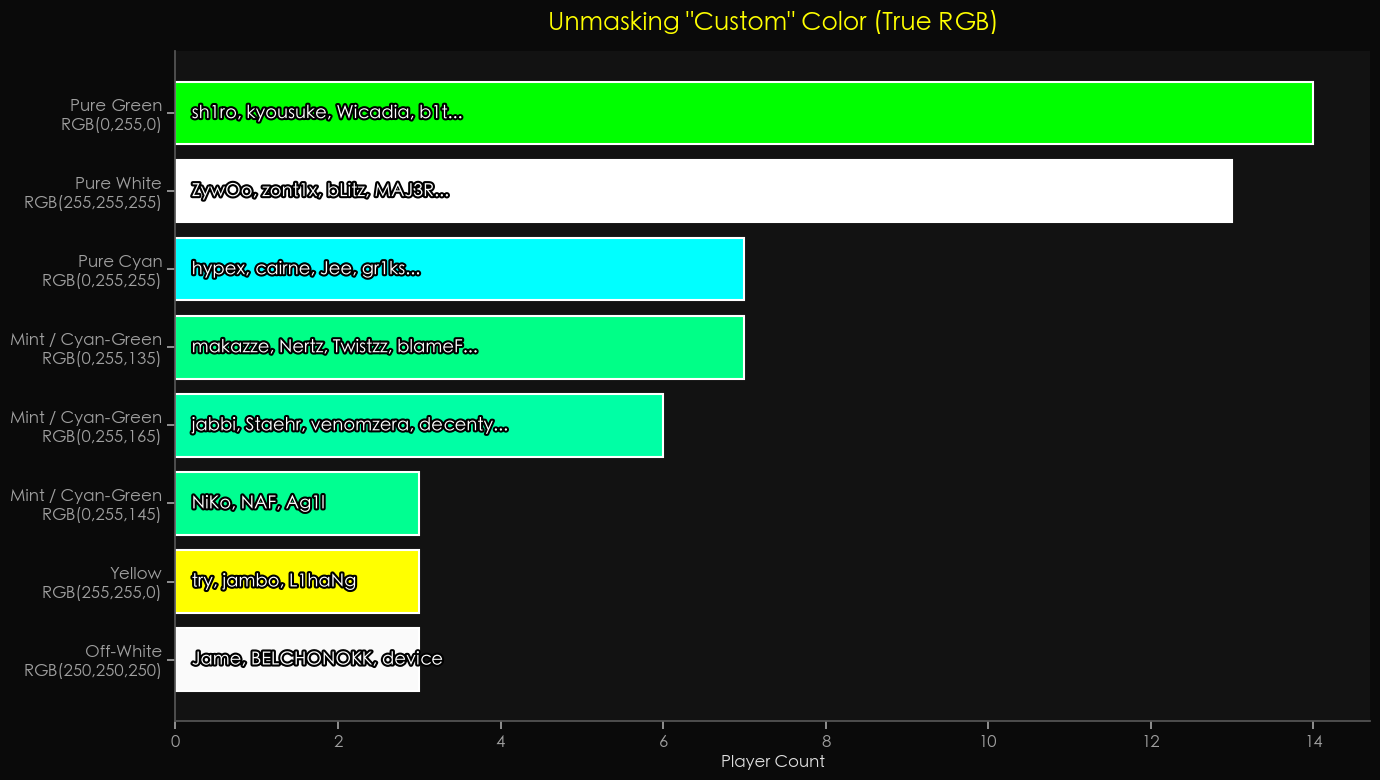

In [22]:
cx = df.dropna(subset=['Gap', 'Length', 'Thickness', 'Color']).copy()

# ---- Crosshair Geometry ----
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=cx, x='Gap', y='Length', size='Thickness', hue='Dot',
                sizes=(20, 400), alpha=0.7, palette=['#00E5FF', '#FF00FF'], ax=ax, edgecolor='w')
ax.set_title('Crosshair Geometry (Gap vs Length)', fontsize=18, fontweight='bold', color='#00FF00', pad=15)
ax.axvline(0, color='#555555', linestyle='--')
sns.despine(ax=ax, left=True, bottom=True)
save('Crosshair Geometry.png'); plt.show()

# ---- Base Color ----
fig, ax = plt.subplots(figsize=(10, 6))
cc = cx['Color'].value_counts().reset_index(); cc.columns = ['Color', 'Count']
color_map = {'Green':'#00FF00','Cyan':'#00FFFF','Yellow':'#FFFF00','Red':'#FF0000',
             'Blue':'#0055FF','Pink':'#FF00FF','Light Blue':'#00A8FF','Custom':'#AAAAAA'}
bar(ax, cc, x_col='Count', y_col='Color',
    title='Base Color Preference', palette=[color_map.get(c,'#888888') for c in cc['Color']], orient='h')
ax.set_ylabel(''); ax.set_xlabel('Player Count', fontsize=12)
plt.tight_layout()
save('Base Color.png'); plt.show()

# ---- Dot & Outline ----
fig, ax = plt.subplots(figsize=(8, 8))
cx['Toggle'] = 'Dot:' + cx['Dot'].astype(str) + ' | Outline:' + cx['Outline'].astype(str)
pie(ax, cx['Toggle'].value_counts(), title='Visibility Toggles (Dot & Outline)', palette_name='Set2')
save('Dot and Outline.png'); plt.show()

# ---- Custom RGB ----
import matplotlib.patheffects as pe
fig, ax = plt.subplots(figsize=(14, 8))
cu = df[df['Color']=='Custom'].dropna(subset=['Red','Green','Blue']).copy()
for c in ['Red','Green','Blue']: cu[c] = cu[c].astype(int)

def hexcolor(r,g,b):
    return '#{:02x}{:02x}{:02x}'.format(*[max(0,min(x,255)) for x in (r,g,b)]).upper()

def colorname(r,g,b):
    if (r,g,b)==(255,255,255): return 'Pure White'
    if (r,g,b)==(0,255,255): return 'Pure Cyan'
    if (r,g,b)==(255,0,255): return 'Magenta'
    if (r,g,b)==(0,255,0): return 'Pure Green'
    if r==250 and g==250 and b==250: return 'Off-White'
    if g>200 and r<100 and b<100: return 'Neon Green'
    if g>200 and b>120 and r<100: return 'Mint / Cyan-Green'
    if r>200 and g>200 and b<100: return 'Yellow'
    return 'Custom Mix'

cu['Hex'] = cu.apply(lambda r: hexcolor(r['Red'],r['Green'],r['Blue']), axis=1)
cu['Name'] = cu.apply(lambda r: colorname(r['Red'],r['Green'],r['Blue']), axis=1)
cu['Label'] = 'RGB(' + cu['Red'].astype(str)+','+cu['Green'].astype(str)+','+cu['Blue'].astype(str) + ')'

top = cu.groupby(['Label','Hex','Name']).size().reset_index(name='Count')
top = top.sort_values('Count', ascending=False).head(8).reset_index(drop=True)
top['Display'] = top['Name'] + '\n' + top['Label']

ax.barh(top['Display'], top['Count'], color=top['Hex'], edgecolor='#FFFFFF', linewidth=1.5)
ax.invert_yaxis()
ax.set_title('Unmasking "Custom" Color (True RGB)', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.set_xlabel('Player Count', fontsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for i, row in top.iterrows():
    players = cu[cu['Label']==row['Label']]['Player'].tolist()
    txt = ax.text(0.2, i, ', '.join(players[:4]) + ('...' if len(players)>4 else ''),
                  va='center', ha='left', fontsize=13, color='white', style='italic', fontweight='bold')
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground='#000000')])
plt.tight_layout()
save('Custom Color.png'); plt.show()

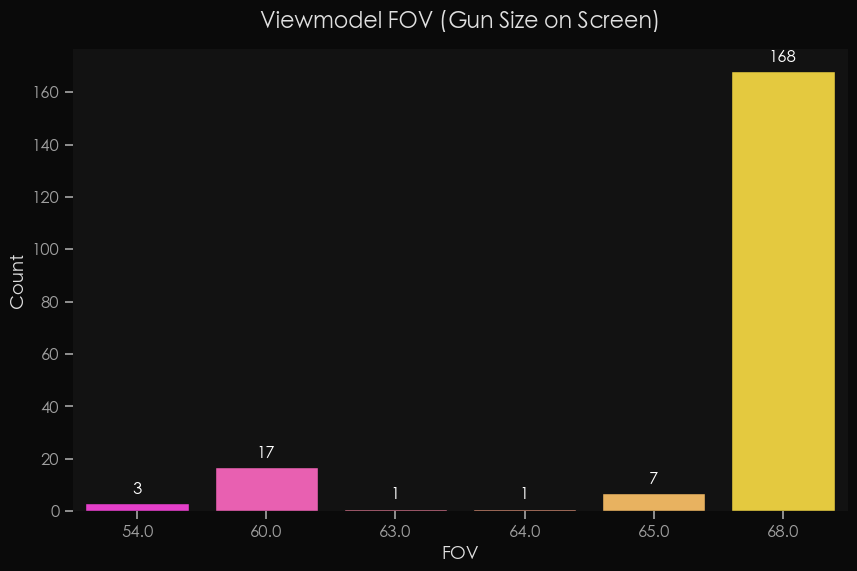

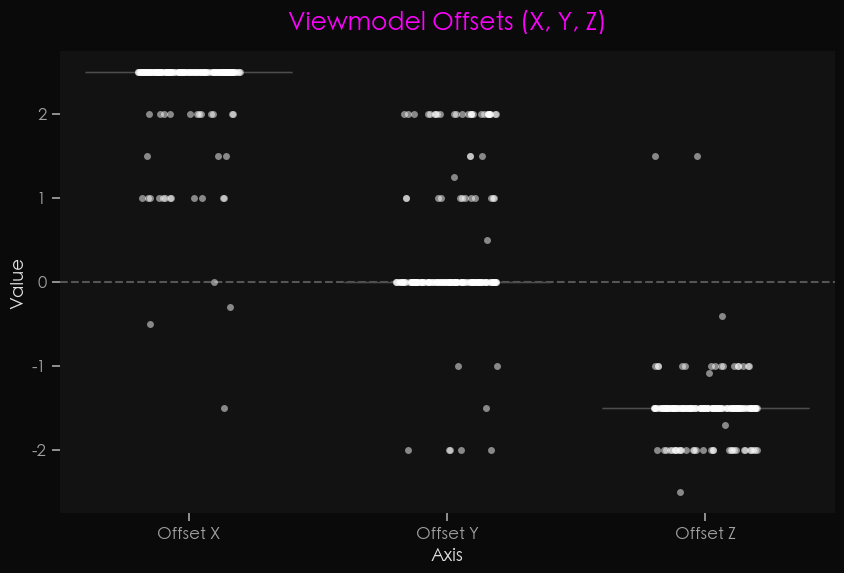

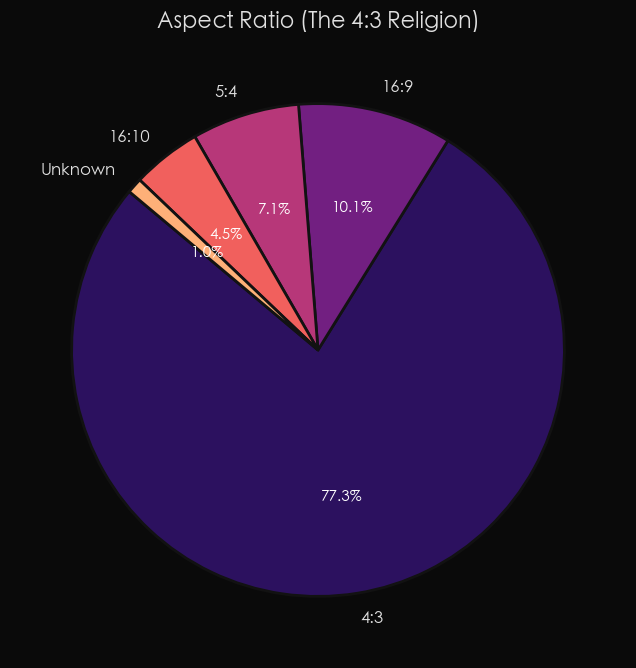

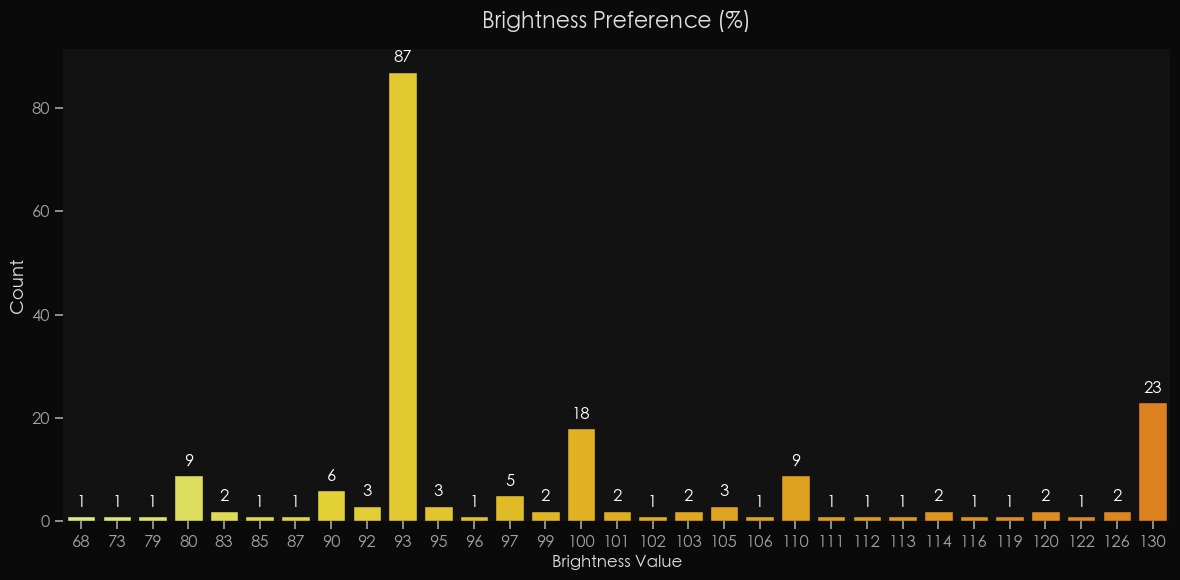

In [23]:
# ---- Viewmodel FOV ----
fig, ax = plt.subplots(figsize=(10, 6))
fv = df.dropna(subset=['FOV'])['FOV'].value_counts().reset_index()
fv.columns = ['FOV', 'Count']
bar(ax, fv, x_col='FOV', y_col='Count', title='Viewmodel FOV (Gun Size on Screen)', palette='spring')
save('FOV.png'); plt.show()

# ---- Viewmodel Offsets XYZ ----
fig, ax = plt.subplots(figsize=(10, 6))
offsets = df[['Offset X','Offset Y','Offset Z']].melt(var_name='Axis', value_name='Value')
sns.boxplot(x='Axis', y='Value', data=offsets, palette=['#00E5FF','#00FF00','#FF00FF'],
            boxprops=dict(alpha=0.6), showfliers=False, ax=ax)
sns.stripplot(x='Axis', y='Value', data=offsets, color='white', alpha=0.5, jitter=0.2, size=5, ax=ax)
ax.axhline(0, color='#555555', linestyle='--')
ax.set_title('Viewmodel Offsets (X, Y, Z)', fontsize=18, fontweight='bold', color='#FF00FF', pad=15)
sns.despine(ax=ax, left=True, bottom=True)
save('Offsets.png'); plt.show()

# ---- Aspect Ratio ----
fig, ax = plt.subplots(figsize=(8, 8))
pie(ax, df['Aspect Ratio'].value_counts(), title='Aspect Ratio (The 4:3 Religion)', palette_name='magma')
save('Ratio Religion.png'); plt.show()

# ---- Brightness ----
fig, ax = plt.subplots(figsize=(12, 6))
df['Br_num'] = pd.to_numeric(df['Brightness'].astype(str).str.replace('%',''), errors='coerce')
br = df.dropna(subset=['Br_num']).copy(); br['Brightness'] = br['Br_num'].astype(int)
bc = br['Brightness'].value_counts().sort_index().reset_index()
bc.columns = ['Brightness', 'Count']
bar(ax, bc, x_col='Brightness', y_col='Count', title='Brightness Preference (%)', palette='Wistia')
ax.set_xlabel('Brightness Value', fontsize=12)
plt.tight_layout()
save('Brightness.png'); plt.show()

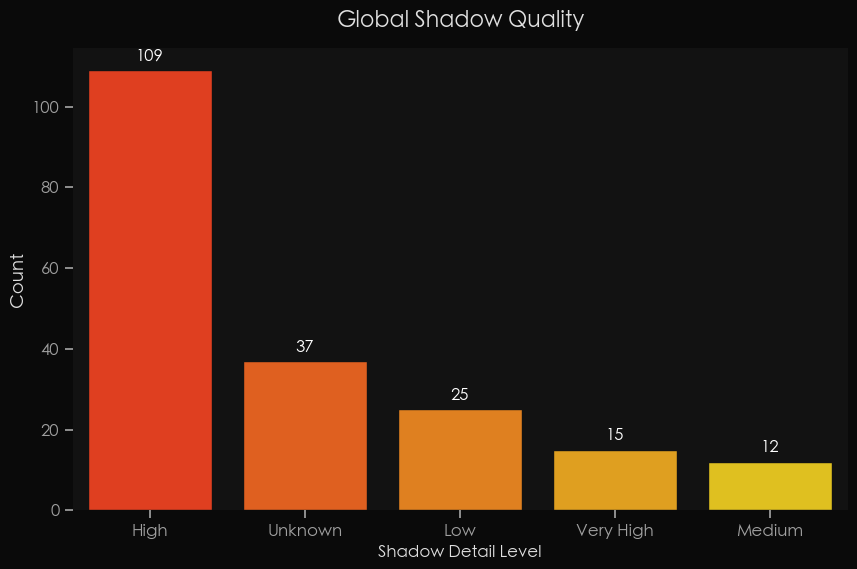

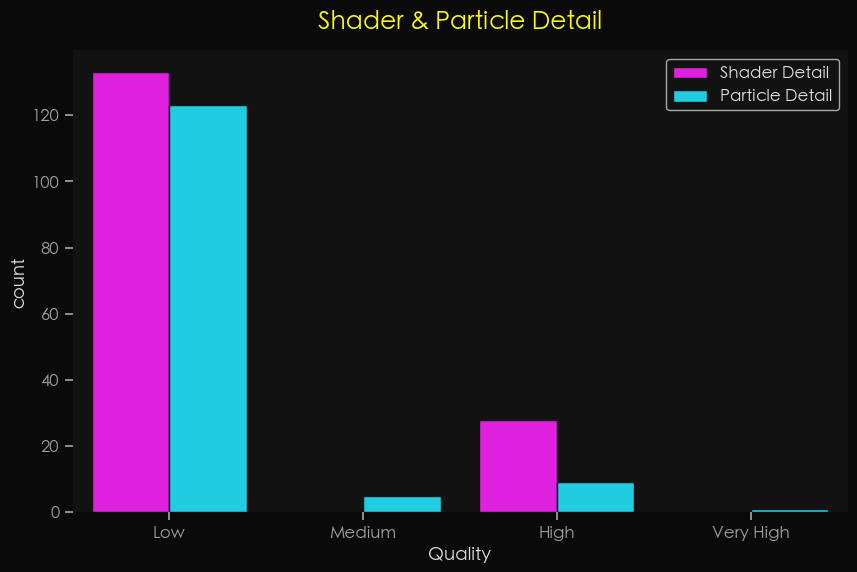

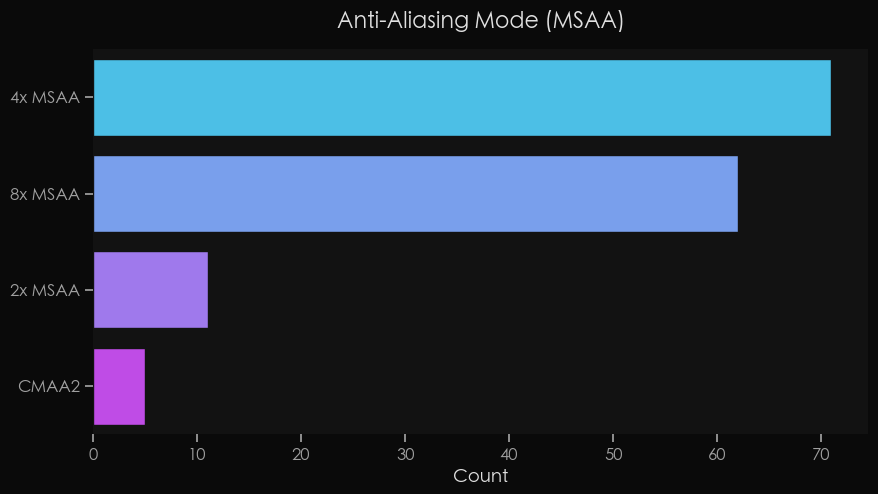

In [24]:
# ---- Global Shadow Quality ----
fig, ax = plt.subplots(figsize=(10, 6))
sc = df['Global Shadow Quality'].value_counts().reset_index()
sc.columns = ['Quality', 'Count']
bar(ax, sc, x_col='Quality', y_col='Count', title='Global Shadow Quality', palette='autumn')
ax.set_xlabel('Shadow Detail Level', fontsize=12)
save('Global Shadow Quality.png'); plt.show()

# ---- Shader & Particle Detail ----
fig, ax = plt.subplots(figsize=(10, 6))
sp = df[['Shader Detail','Particle Detail']].melt(var_name='Setting', value_name='Quality')
sp = sp[sp['Quality'] != 'Unknown']
sns.countplot(data=sp, x='Quality', hue='Setting', order=['Low','Medium','High','Very High'],
              palette=['#FF00FF','#00E5FF'], ax=ax, edgecolor='#121212')
ax.set_title('Shader & Particle Detail', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.legend(facecolor='#121212')
sns.despine(ax=ax, left=True, bottom=True)
save('Shader and Particle.png'); plt.show()

# ---- MSAA ----
fig, ax = plt.subplots(figsize=(10, 5))
ms = df[df['Multisampling Anti-Aliasing Mode'] != 'Unknown']
mc = ms['Multisampling Anti-Aliasing Mode'].value_counts().reset_index()
mc.columns = ['Mode', 'Count']
bar(ax, mc, x_col='Count', y_col='Mode', title='Anti-Aliasing Mode (MSAA)', palette='cool', orient='h')
ax.set_ylabel('')
save('Anti-Aliasing.png'); plt.show()

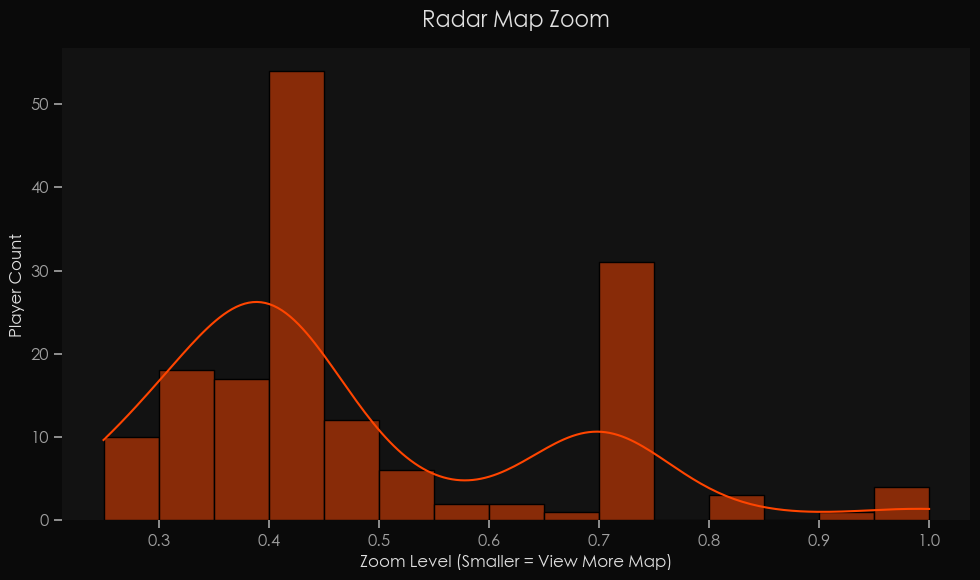

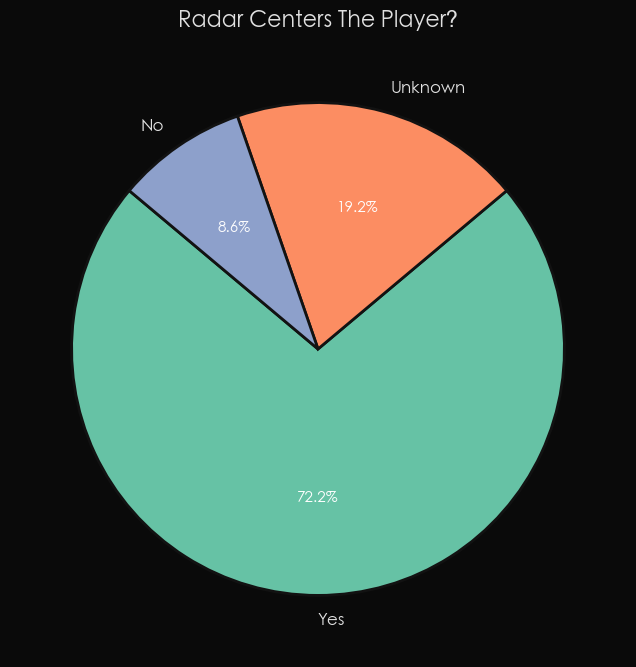

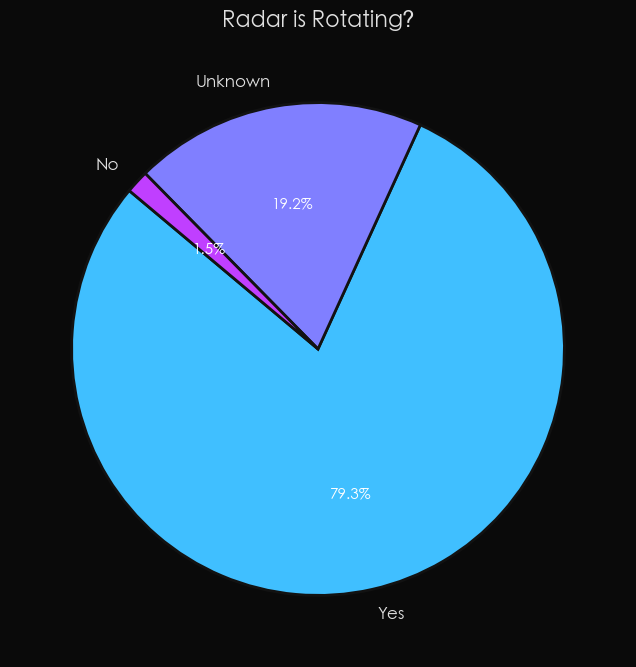

In [25]:
# ---- Radar Zoom ----
fig, ax = plt.subplots(figsize=(10, 6))
hist(ax, df['Radar Map Zoom'].dropna(), title='Radar Map Zoom', color='#FF4500', bins=15)
ax.set_xlabel('Zoom Level (Smaller = View More Map)', fontsize=12)
ax.set_ylabel('Player Count', fontsize=12)
plt.tight_layout()
save('Map Zoom.png'); plt.show()

# ---- Radar Centers Player ----
fig, ax = plt.subplots(figsize=(8, 8))
pie(ax, df['Radar Centers The Player'].value_counts(), title='Radar Centers The Player?', palette_name='Set2')
save('Radar Center.png'); plt.show()

# ---- Radar Rotating ----
fig, ax = plt.subplots(figsize=(8, 8))
pie(ax, df['Radar is Rotating'].value_counts(), title='Radar is Rotating?', palette_name='cool')
save('Radar Rotate.png'); plt.show()

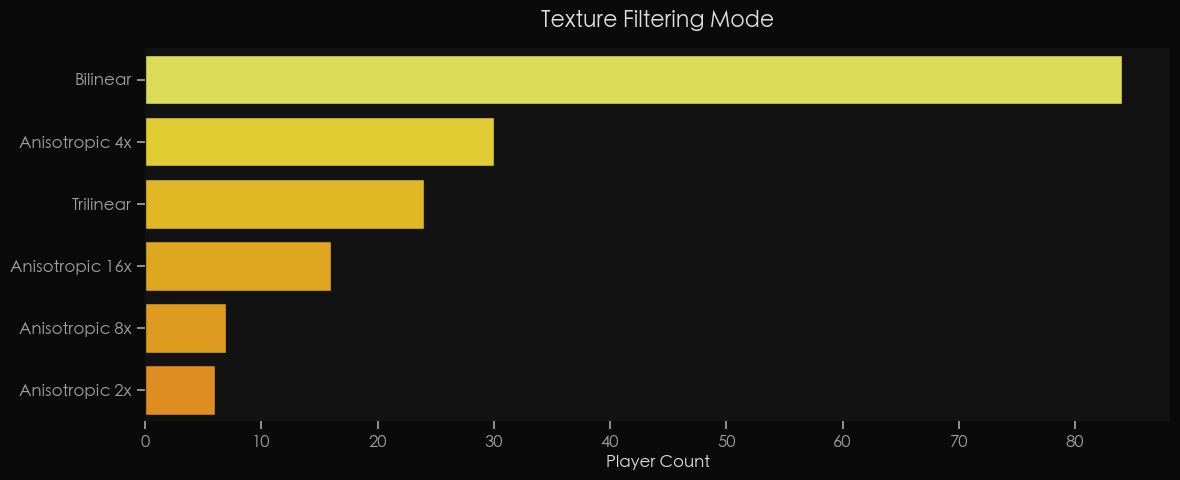

In [26]:
# ---- Texture Filtering Mode ----
fig, ax = plt.subplots(figsize=(12, 5))
tf = df[df['Texture Filtering Mode'] != 'Unknown']['Texture Filtering Mode'].value_counts().reset_index()
tf.columns = ['Mode', 'Count']
bar(ax, tf, x_col='Count', y_col='Mode', title='Texture Filtering Mode', palette='Wistia', orient='h')
ax.set_ylabel(''); ax.set_xlabel('Player Count', fontsize=12)
plt.tight_layout()
save('Texture Filtering Mode.png'); plt.show()

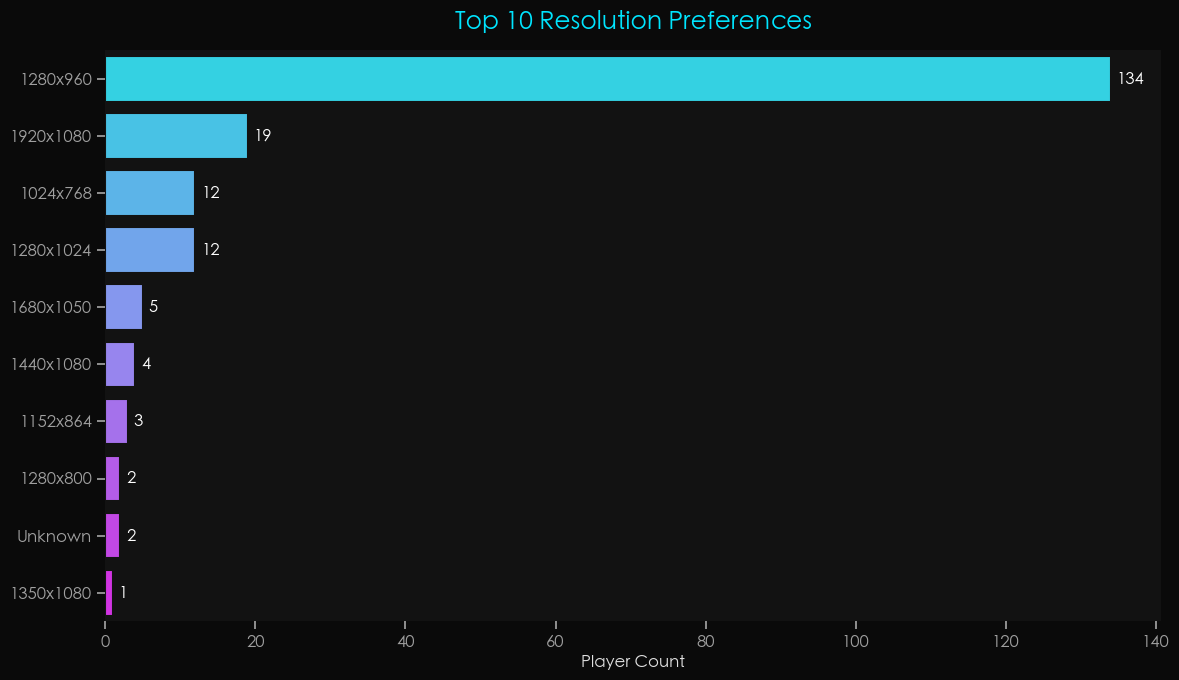

In [27]:
# ---- Resolution Top 10 ----
fig, ax = plt.subplots(figsize=(12, 7))
rc = df['Resolution'].value_counts().head(10).reset_index()
rc.columns = ['Resolution', 'Count']
sns.barplot(data=rc, x='Count', y='Resolution', palette='cool', ax=ax, edgecolor='#121212', linewidth=1.5)
ax.set_title('Top 10 Resolution Preferences', fontsize=18, fontweight='bold', color='#00E5FF', pad=15)
ax.set_xlabel('Player Count', fontsize=12); ax.set_ylabel('')
sns.despine(ax=ax, left=True, bottom=True)
for p in ax.patches:
    w = p.get_width()
    if not np.isnan(w) and w > 0:
        ax.text(w + 0.8, p.get_y() + p.get_height()/2., f'{int(w)}',
                ha='left', va='center', fontsize=12, fontweight='bold', color='white')
plt.tight_layout()
save('resolution.png'); plt.show()